Sourcing environment

# From anywhere
source /home/acrfa/ml-class/.venv/bin/activate

# From inside the folder
cd /home/acrfa/ml-class
source .venv/bin/activate

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
%matplotlib inline

Step 1: points for red and blue
Step 2: 

In [3]:
def mapminmax_apply(data, ymin=0, ymax=1):
    """Normalize data to [ymin, ymax]. Returns normalized data and params."""
    dmin = data.min(axis=1, keepdims=True)
    dmax = data.max(axis=1, keepdims=True)
    data_n = (ymax - ymin) * (data - dmin) / (dmax - dmin) + ymin
    params = {'dmin': dmin, 'dmax': dmax, 'ymin': ymin, 'ymax': ymax}
    return data_n, params

def mapminmax_apply_with_params(data, params):
    """Apply normalization using saved params."""
    return (params['ymax'] - params['ymin']) * (data - params['dmin']) / (params['dmax'] - params['dmin']) + params['ymin']


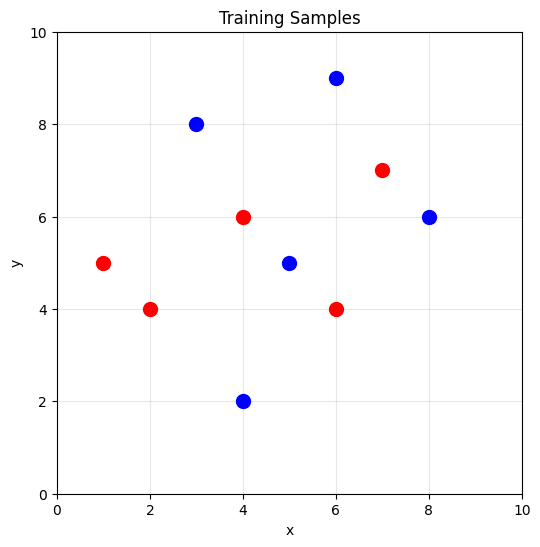

In [4]:

input_cls = np.array      ([[1, 2, 7, 4, 6, 6, 4, 8, 5, 3],
                            [5, 4, 7, 6, 4, 9, 2, 6, 5, 8]], dtype=float)
red_or_blue_cls = np.array([[0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
                            [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]], dtype=float)
# (1) The coordinates of the red dots: (1, 5); (2, 4); (7, 7); (4,6); (6,4)
# (2) The coordinate of the blue dots: (6, 9); (4, 2); (8, 6); (5, 5); (3, 8)
# Visualize training samples
plt.figure(figsize=(6, 6))
for i in range(input_cls.shape[1]):
    if red_or_blue_cls[0, i] > red_or_blue_cls[1, i]:
        plt.plot(input_cls[0, i], input_cls[1, i], 'bo', markersize=10)
    else:
        plt.plot(input_cls[0, i], input_cls[1, i], 'ro', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Samples')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
# Normalize the training samples to [0, 1]
input_cls_normalized, ps_cls = mapminmax_apply(input_cls, 0, 1)
# R is already within (0, 1) due to softmax, so no normalization needed for R

print(f"Normalized X:\n{input_cls_normalized}")

# Determine the number of training samples: N
number_training_samples_cls = input_cls.shape[1]
print(f"\nNumber of training samples: N = {number_training_samples_cls}")

Normalized X:
[[0.         0.14285714 0.85714286 0.42857143 0.71428571 0.71428571
  0.42857143 1.         0.57142857 0.28571429]
 [0.42857143 0.28571429 0.71428571 0.57142857 0.28571429 1.
  0.         0.57142857 0.42857143 0.85714286]]

Number of training samples: N = 10


In [6]:
# Initialization
num_hidden_nodes = 80       # H is the number of hidden units
num_output_nodes = 2        # 2 output classes
num_input_nodes = 2        # 2 inputs

value_input = np.zeros((num_input_nodes, 1))         # the input neurons
value_ground_truth = np.zeros((num_output_nodes, 1)) # the target for each input
value_hidden1 = np.zeros((num_hidden_nodes, 1))       # the outputs of the hidden neurons
value_hidden2 = np.zeros((num_hidden_nodes, 1))       # the outputs of the hidden neurons
value_hidden3 = np.zeros((num_hidden_nodes, 1))       # the outputs of the hidden neurons
value_output = np.zeros((num_output_nodes, 1))       # the output neurons

weights_hidden1 = np.ones((num_input_nodes, num_hidden_nodes))    # weights w (input->hidden): 2 x H
weights_hidden2 = np.ones((num_hidden_nodes, num_hidden_nodes))   # weights w (input->hidden): H x H
weights_hidden3 = np.ones((num_hidden_nodes, num_hidden_nodes))   # weights w (input->hidden): H x H
weights_hidden_to_output = np.ones((num_hidden_nodes, num_output_nodes))   # weights v (hidden->output): H x 2


gradient_hidden1 = np.zeros((num_input_nodes, num_hidden_nodes))  # initialize delta_w
gradient_hidden2 = np.zeros((num_hidden_nodes, num_hidden_nodes))  # initialize delta_w
gradient_hidden3 = np.zeros((num_hidden_nodes, num_hidden_nodes))  # initialize delta_w
gradient_hidden_to_output = np.zeros((num_hidden_nodes, num_output_nodes))  # initialize delta_v

learning_rate = 0.01    # define the learning rate

# Initialize w using random numbers within (-0.01, 0.01)
np.random.seed(42)
for i in range(num_input_nodes):
    for h in range(num_hidden_nodes):
        weights_hidden1[i, h] = (0.01 - (-0.01)) * np.random.rand() + (-0.01)

# Initialize v using random numbers within (-0.01, 0.01)
for h in range(num_hidden_nodes):
    for k in range(num_output_nodes):
        weights_hidden_to_output[h, k] = (0.01 - (-0.01)) * np.random.rand() + (-0.01)

print(f"Hidden units: H = {num_hidden_nodes}")
print(f"Output units: K = {num_output_nodes}")
print(f"Learning rate: eta = {learning_rate}")
print("Weights initialized to small random values in (-0.01, 0.01).")

Hidden units: H = 80
Output units: K = 2
Learning rate: eta = 0.01
Weights initialized to small random values in (-0.01, 0.01).


In [7]:
for i in range(1, 11):
    print(i)

1
2
3
4
5
6
7
8
9
10


In [ ]:
# ========== BP Algorithm for Classification ==========
# Training the neural network for 3,000 steps

epochs = 3000  # select the total training steps
count_cls = 0
v_history_cls = []
w_history_cls = []
err_history_cls = []

#for i in range(1,epochs+1) #Iterates 3000 times
    #Start of BP

    #Iterate 6 times
        
        
        #Calculate error for y

        #Calculate gradient

        #Update weights with new gradients



for j in range(1, epochs + 1):
    # Take all training samples into the BP algorithm
    err_cls = 0
    for t in range(number_training_samples_cls):
        # Generate a random number between 0 and N-1
        c = int(np.round((number_training_samples_cls - 1) * np.random.rand()))
        #c = int
        value_input = input_cls_normalized[:, c:c+1]   # randomly select a sample
        r_cls = red_or_blue_cls[:, c:c+1]

        # Calculate the outputs of the hidden layer 1
        for h in range(num_hidden_nodes):
            w_num_hidden1_nodes = weights_hidden1[:, h:h+1]  # weight column for hidden unit h
            value_hidden1[h, 0] = 1.0 / (1.0 + np.exp(-(w_num_hidden1_nodes.T @ value_input).item()))  # sigmoid
        
        # Calculate the outputs of the hidden layer 2
        for h in range(num_hidden_nodes):
            w_num_hidden2_nodes = weights_hidden2[:, h:h+1]  # weight column for hidden unit h
            value_hidden2[h, 0] = 1.0 / (1.0 + np.exp(-(w_num_hidden2_nodes.T @ value_hidden1).item()))  # sigmoid
        
        # Calculate the outputs of the hidden layer 3
        for h in range(num_hidden_nodes):
            w_num_hidden3_nodes = weights_hidden3[:, h:h+1]  # weight column for hidden unit h
            value_hidden3[h, 0] = 1.0 / (1.0 + np.exp(-(w_num_hidden3_nodes.T @ value_hidden2).item()))  # sigmoid
        

        # Calculate the output of the output layer: y
        sum_exp = 0
        for k in range(num_output_nodes):
           value_output[k, 0] = (weights_hidden_to_output[:, k:k+1].T @ value_hidden3).item()
           value_output[k, 0] = np.exp(value_output[k, 0])
           sum_exp +=value_output[k, 0]

        # Softmax activation function
        for k in range(num_output_nodes):
           value_output[k, 0] =value_output[k, 0] / sum_exp
           err_cls += abs(r_cls[k, 0] -value_output[k, 0])  # calculate the error

        # Calculate output 
        for k in range(num_output_nodes):
            gradient_hidden_to_output[:, k:k+1] = learning_rate * (r_cls[k, 0] -value_output[k, 0]) * value_hidden3

        
        # Calculate hidden 3
        for h in range(num_hidden_nodes):
            sum_val = 0
            for k in range(num_output_nodes):
                sum_val += (r_cls[k, 0] -value_output[k, 0]) * weights_hidden_to_output[h, k]
            gradient_hidden3[:, h:h+1] = learning_rate * sum_val * value_hidden3[h, 0] * (1 - value_hidden3[h, 0]) * value_hidden2

        
        # Calculate hidden 2
        for h in range(num_hidden_nodes):
            sum_val = 0
            for k in range(num_hidden_nodes):
                sum_val += (gradient_hidden3[k, 0]) * weights_hidden3[h, k]
            gradient_hidden2[:, h:h+1] = learning_rate * sum_val * value_hidden2[h, 0] * (1 - value_hidden2[h, 0]) * value_hidden1
        
        # Calculate hidden 1
        for h in range(num_hidden_nodes):
            sum_val = 0
            for k in range(num_hidden_nodes):
                sum_val += (gradient_hidden2[k, 0]) * weights_hidden2[h, k]
            gradient_hidden1[:, h:h+1] = learning_rate * sum_val * value_hidden1[h, 0] * (1 - value_hidden1[h, 0]) * value_input

        # Update v
        weights_hidden_to_output = weights_hidden_to_output + gradient_hidden_to_output
        weights_hidden2 = weights_hidden2 + gradient_hidden2
        weights_hidden3 = weights_hidden3 + gradient_hidden3
        weights_hidden1 = weights_hidden1 + gradient_hidden1
        # Save weight history
        count_cls += 1
        w_history_cls.append(weights_hidden1[0, min(3, num_hidden_nodes-1)])
        v_history_cls.append(weights_hidden_to_output[min(4, num_hidden_nodes-1), 0])
        
    err_history_cls.append(err_cls / (number_training_samples_cls * 2.0))  # save the history of error
    if j % 100 == 0:
        print(f"Step {j}/{epochs}, Error = {err_history_cls[-1]:.6f}")

print(f"\nTraining complete. Final error = {err_history_cls[-1]:.6f}")

Step 100/3000, Error = 0.542715
Step 200/3000, Error = 0.411176
Step 300/3000, Error = 0.517333
Step 400/3000, Error = 0.446124
Step 500/3000, Error = 0.476742
Step 600/3000, Error = 0.436867
Step 700/3000, Error = 0.538078
Step 800/3000, Error = 0.539584
Step 900/3000, Error = 0.373962
Step 1000/3000, Error = 0.490698
Step 1100/3000, Error = 0.500354
Step 1200/3000, Error = 0.462304
Step 1300/3000, Error = 0.512249
Step 1400/3000, Error = 0.467383
Step 1500/3000, Error = 0.345068
Step 1600/3000, Error = 0.555479
Step 1700/3000, Error = 0.501745
Step 1800/3000, Error = 0.454129
Step 1900/3000, Error = 0.519414
Step 2000/3000, Error = 0.437287
Step 2100/3000, Error = 0.566461
Step 2200/3000, Error = 0.497700
Step 2300/3000, Error = 0.554270
Step 2400/3000, Error = 0.481815
Step 2500/3000, Error = 0.497987
Step 2600/3000, Error = 0.388718
Step 2700/3000, Error = 0.582357
Step 2800/3000, Error = 0.508360
Step 2900/3000, Error = 0.486248
Step 3000/3000, Error = 0.482031

Training complete.

In [20]:
for j in range(1, epochs + 1):
    err_cls = 0
    for t in range(number_training_samples_cls):
        c = int(np.round((number_training_samples_cls - 1) * np.random.rand()))
        value_input = input_cls_normalized[:, c:c+1]
        r_cls = red_or_blue_cls[:, c:c+1]

        # Calculate the outputs of the hidden layer 1
        for h in range(num_hidden_nodes):
            w_num_hidden1_nodes = weights_hidden1[:, h:h+1]
            value_hidden1[h, 0] = 1.0 / (1.0 + np.exp(-(w_num_hidden1_nodes.T @ value_input).item()))

        # Calculate the outputs of the hidden layer 2
        for h in range(num_hidden_nodes):
            w_num_hidden2_nodes = weights_hidden2[:, h:h+1]
            value_hidden2[h, 0] = 1.0 / (1.0 + np.exp(-(w_num_hidden2_nodes.T @ value_hidden1).item()))

        # Calculate the outputs of the hidden layer 3
        for h in range(num_hidden_nodes):
            w_num_hidden3_nodes = weights_hidden3[:, h:h+1]
            value_hidden3[h, 0] = 1.0 / (1.0 + np.exp(-(w_num_hidden3_nodes.T @ value_hidden2).item()))

        # Calculate the output of the output layer
        sum_exp = 0
        for k in range(num_output_nodes):
            value_output[k, 0] = (weights_hidden_to_output[:, k:k+1].T @ value_hidden3).item()
            value_output[k, 0] = np.exp(value_output[k, 0])
            sum_exp += value_output[k, 0]

        # Softmax activation function
        for k in range(num_output_nodes):
            value_output[k, 0] = value_output[k, 0] / sum_exp
            err_cls += abs(r_cls[k, 0] - value_output[k, 0])

        # Calculate gradient for output layer
        for k in range(num_output_nodes):
            gradient_hidden_to_output[:, k:k+1] = learning_rate * (r_cls[k, 0] - value_output[k, 0]) * value_hidden3

        # Calculate gradient for hidden 3 — NO CHANGE
        for h in range(num_hidden_nodes):
            sum_val = 0
            for k in range(num_output_nodes):
                sum_val += (r_cls[k, 0] - value_output[k, 0]) * weights_hidden_to_output[h, k]
            gradient_hidden3[:, h:h+1] = learning_rate * sum_val * value_hidden3[h, 0] * (1 - value_hidden3[h, 0]) * value_hidden2

        # Calculate gradient for hidden 2 — CHANGED: loop over hidden nodes, sum gradient_hidden3 * weights_hidden3
        for h in range(num_hidden_nodes):
            sum_val = 0
            for hh in range(num_hidden_nodes):  # CHANGED from num_output_nodes to num_hidden_nodes
                sum_val += gradient_hidden3[hh, 0] * weights_hidden3[h, hh]  # CHANGED from output error * output weights
            gradient_hidden2[:, h:h+1] = learning_rate * sum_val * value_hidden2[h, 0] * (1 - value_hidden2[h, 0]) * value_hidden1

        # Calculate gradient for hidden 1 — CHANGED: loop over hidden nodes, sum gradient_hidden2 * weights_hidden2
        for h in range(num_hidden_nodes):
            sum_val = 0
            for hh in range(num_hidden_nodes):  # CHANGED from num_output_nodes to num_hidden_nodes
                sum_val += gradient_hidden2[hh, 0] * weights_hidden2[h, hh]  # CHANGED from output error * output weights
            gradient_hidden1[:, h:h+1] = learning_rate * sum_val * value_hidden1[h, 0] * (1 - value_hidden1[h, 0]) * value_input

        # Update all weights
        weights_hidden_to_output = weights_hidden_to_output + gradient_hidden_to_output
        weights_hidden3 = weights_hidden3 + gradient_hidden3
        weights_hidden2 = weights_hidden2 + gradient_hidden2
        weights_hidden1 = weights_hidden1 + gradient_hidden1

        count_cls += 1
        w_history_cls.append(weights_hidden1[0, min(3, num_hidden_nodes-1)])
        v_history_cls.append(weights_hidden_to_output[min(4, num_hidden_nodes-1), 0])

    err_history_cls.append(err_cls / (number_training_samples_cls * 2.0))
    if j % 100 == 0:
        print(f"Step {j}/{epochs}, Error = {err_history_cls[-1]:.6f}")

print(f"\nTraining complete. Final error = {err_history_cls[-1]:.6f}")

Step 100/3000, Error = 0.566647
Step 200/3000, Error = 0.604837
Step 300/3000, Error = 0.487805
Step 400/3000, Error = 0.541676
Step 500/3000, Error = 0.440442
Step 600/3000, Error = 0.580316
Step 700/3000, Error = 0.562246
Step 800/3000, Error = 0.610000
Step 900/3000, Error = 0.538373
Step 1000/3000, Error = 0.547530
Step 1100/3000, Error = 0.560125
Step 1200/3000, Error = 0.575855
Step 1300/3000, Error = 0.481411
Step 1400/3000, Error = 0.566851
Step 1500/3000, Error = 0.510211
Step 1600/3000, Error = 0.518663
Step 1700/3000, Error = 0.466428
Step 1800/3000, Error = 0.421562
Step 1900/3000, Error = 0.481405
Step 2000/3000, Error = 0.551471
Step 2100/3000, Error = 0.538384
Step 2200/3000, Error = 0.358772
Step 2300/3000, Error = 0.537941
Step 2400/3000, Error = 0.548266
Step 2500/3000, Error = 0.528486
Step 2600/3000, Error = 0.569640
Step 2700/3000, Error = 0.552314
Step 2800/3000, Error = 0.539120
Step 2900/3000, Error = 0.541109
Step 3000/3000, Error = 0.381077

Training complete.

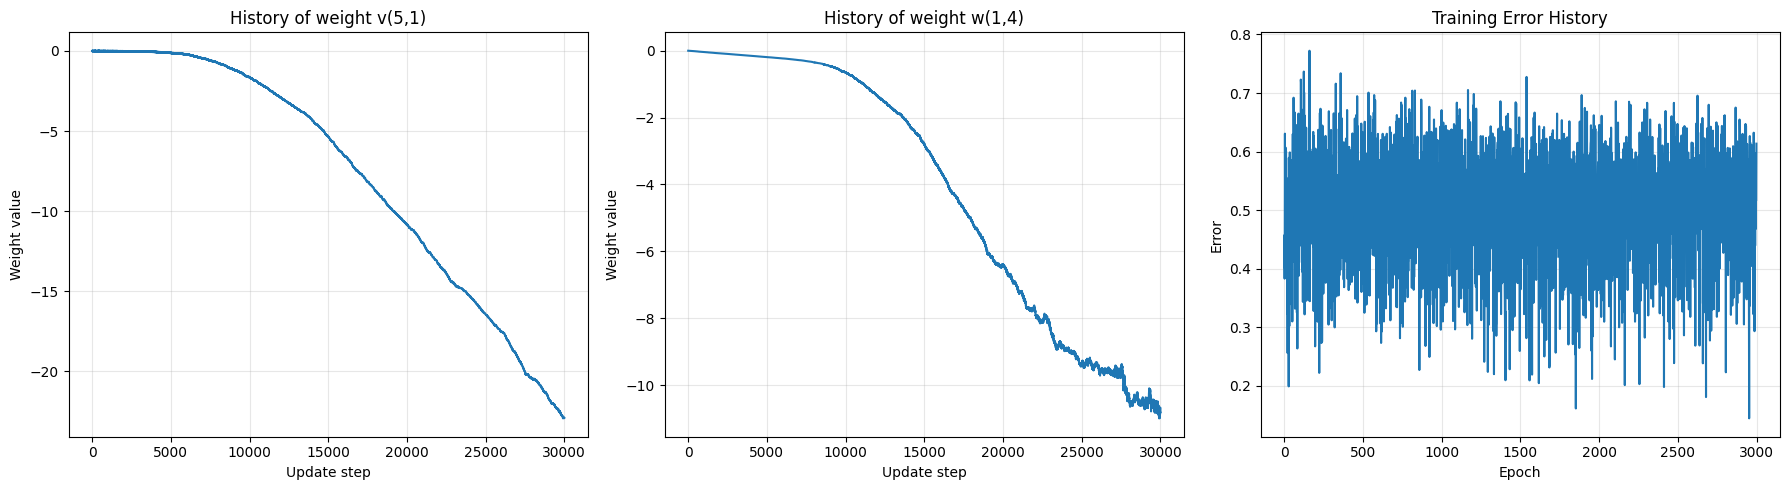

In [13]:
# Show the training results

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot weight v history
axes[0].plot(v_history_cls)
axes[0].set_title('History of weight v(5,1)')
axes[0].set_xlabel('Update step')
axes[0].set_ylabel('Weight value')
axes[0].grid(True, alpha=0.3)

# Plot weight w history
axes[1].plot(w_history_cls)
axes[1].set_title('History of weight w(1,4)')
axes[1].set_xlabel('Update step')
axes[1].set_ylabel('Weight value')
axes[1].grid(True, alpha=0.3)

# Plot error history
axes[2].plot(err_history_cls)
axes[2].set_title('Training Error History')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Error')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_15421/3962172308.py:20: RuntimeWarning: overflow encountered in exp
  Y_t[k, 0] = np.exp(Y_raw[k, 0])
/tmp/ipykernel_15421/3962172308.py:23: RuntimeWarning: invalid value encountered in scalar divide
  Y_t[k, 0] = Y_t[k, 0] / sum_exp


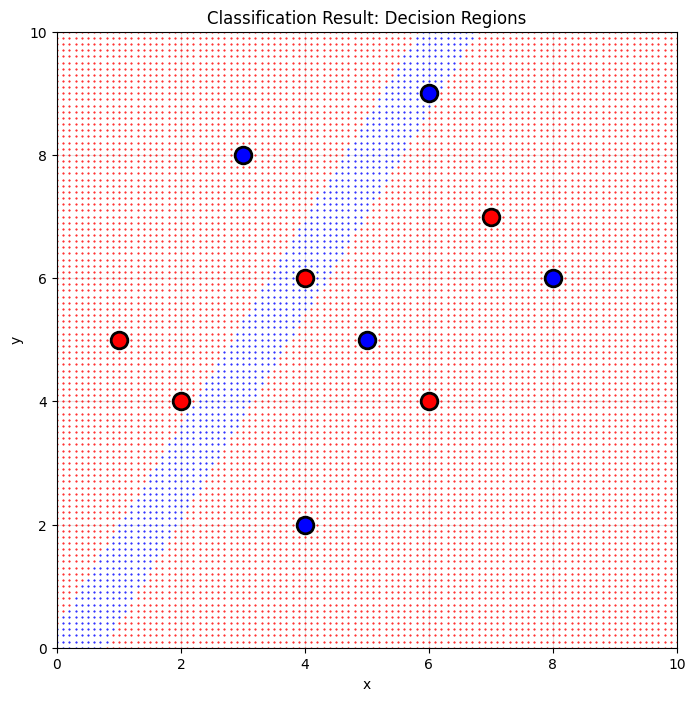

In [14]:
# ========== Test the classification network ==========
#For an 10 x 10 figure this loop runs 100,201 times
plt.figure(figsize=(8, 8))

# Test the network over a grid of points
for x_test in np.arange(0, 10.1, 0.1):
    for y_test in np.arange(0, 10.1, 0.1):
        # Normalize the test sample
        test_input = np.array([[x_test], [y_test]])
        X_n_t = mapminmax_apply_with_params(test_input, ps_cls)
        
        # Forward pass
        Z_t = 1.0 / (1.0 + np.exp(-(weights_hidden1.T @ X_n_t)))  # H x 1
        Y_raw = weights_hidden_to_output.T @ Z_t  # K x 1
        
        # Softmax
        sum_exp = 0
        Y_t = np.zeros((num_output_nodes, 1))
        for k in range(num_output_nodes):
            Y_t[k, 0] = np.exp(Y_raw[k, 0])
            sum_exp += Y_t[k, 0]
        for k in range(num_output_nodes):
            Y_t[k, 0] = Y_t[k, 0] / sum_exp
        
        # Classify
        if Y_t[0, 0] >= Y_t[1, 0]:
            plt.plot(x_test, y_test, 'b.', markersize=1)
        else:
            plt.plot(x_test, y_test, 'r.', markersize=1)

# Plot the training samples on the same figure
for i in range(number_training_samples_cls):
    location = input_cls[:, i]
    x_pt = location[0]
    y_pt = location[1]
    class_label = red_or_blue_cls[:, i]
    if class_label[0] > class_label[1]:
        plt.plot(x_pt, y_pt, 'bo', markersize=12, markeredgecolor='black', markeredgewidth=2)
    else:
        plt.plot(x_pt, y_pt, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Classification Result: Decision Regions')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.grid(True, alpha=0.3)
plt.show()